# 05 — Race Inference v2

**Improvements from v1:**
- Claude Haiku LLM inference (replaces Ollama — v1 returned 'Cannot Infer' 94% of the time)
- LIME explanations (install: `pip install lime`)
- Fixed erasure experiment (was barely changing accuracy — now with proper evaluation)
- New: Latent Dirichlet Allocation probing — do topics separate by race?
- Logistic regression with proper cross-validation and balanced accuracy

In [1]:
import sys
sys.path.insert(0, '../../notebooks')
import config

import json
import re
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from scipy import stats
import matplotlib.pyplot as plt
import anthropic

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

client = anthropic.Anthropic(api_key=config.ANTHROPIC_API_KEY)
print('Ready.')

Ready.


## 1. Load Redacted Data

In [2]:
import os

# Prefer redacted data for fair race inference test
if os.path.exists(config.REDACTED_DATA):
    with open(config.REDACTED_DATA) as f:
        df = pd.DataFrame(json.load(f))
    nar_col = 'narrative_redacted'
    print(f'Using redacted narratives: {len(df)} records')
elif os.path.exists(config.CLEAN_DATA):
    with open(config.CLEAN_DATA) as f:
        df = pd.DataFrame(json.load(f))
    nar_col = 'narrative_clean' if 'narrative_clean' in df.columns else 'narrative'
    print(f'Using original narratives (no redaction): {len(df)} records')
else:
    with open(config.BW_DATASET) as f:
        df = pd.DataFrame(json.load(f))
    df = df[df['race'].isin(['Black','White'])].copy()
    nar_col = 'narrative_clean' if 'narrative_clean' in df.columns else 'narrative'
    print(f'Using BW dataset: {len(df)} records')

df = df[df['race'].isin(['Black','White'])].copy()
df['label'] = (df['race'] == 'Black').astype(int)  # 1=Black, 0=White
print(df['race'].value_counts())

texts = df[nar_col].fillna('').tolist()
labels = df['label'].values

Using redacted narratives: 1000 records
race
Black    500
White    500
Name: count, dtype: int64


## 2. Logistic Regression with TF-IDF (5-fold CV)

In [3]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
sys.path.insert(0, '../../notebooks')

# Stopwords: English + Rochester geographic
STOPWORDS = list(ENGLISH_STOP_WORDS | config.ROCHESTER_STOPWORDS)

# TF-IDF + Logistic Regression pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000, ngram_range=(1,2),
        stop_words=STOPWORDS, min_df=3, sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs'
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)

# Balanced accuracy scores
ba_scores = cross_val_score(pipeline, texts, labels, cv=cv,
                             scoring='balanced_accuracy', n_jobs=-1)

print('Logistic Regression Race Inference (5-fold CV, balanced accuracy):')
print(f'  Scores: {ba_scores.round(4)}')
print(f'  Mean ± SD: {ba_scores.mean():.4f} ± {ba_scores.std():.4f}')
print(f'  95% CI: [{ba_scores.mean()-1.96*ba_scores.std():.4f}, {ba_scores.mean()+1.96*ba_scores.std():.4f}]')

# One-sample t-test against chance (0.5)
t, p = stats.ttest_1samp(ba_scores, 0.5)
print(f'\nAbove chance (0.5)? t={t:.3f}, p={p:.4f}')

# Effect size: Cohen's d
d = (ba_scores.mean() - 0.5) / ba_scores.std()
print(f'Effect size (Cohen\'s d): {d:.3f}')

Logistic Regression Race Inference (5-fold CV, balanced accuracy):
  Scores: [0.63  0.62  0.62  0.555 0.635]
  Mean ± SD: 0.6120 ± 0.0291
  95% CI: [0.5550, 0.6690]

Above chance (0.5)? t=7.701, p=0.0015
Effect size (Cohen's d): 3.851


In [4]:
# Fit on full data for feature analysis
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=config.RANDOM_SEED, stratify=labels
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
ba = balanced_accuracy_score(y_test, y_pred)
print(f'Hold-out balanced accuracy: {ba:.4f}')
print(classification_report(y_test, y_pred, target_names=['White','Black']))

# Top predictive features
tfidf = pipeline.named_steps['tfidf']
clf   = pipeline.named_steps['clf']
features = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]

top_black = pd.DataFrame({'word': features[np.argsort(-coefs)[:30]], 'coef': np.sort(-coefs)[:30]})
top_white = pd.DataFrame({'word': features[np.argsort(coefs)[:30]], 'coef': np.sort(coefs)[:30]})

print('\nTop 20 predictors of BLACK:')
print(top_black.head(20).to_string(index=False))
print('\nTop 20 predictors of WHITE:')
print(top_white.head(20).to_string(index=False))

Hold-out balanced accuracy: 0.5750
              precision    recall  f1-score   support

       White       0.57      0.61      0.59       100
       Black       0.58      0.54      0.56       100

    accuracy                           0.57       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.57      0.57       200


Top 20 predictors of BLACK:
            word      coef
         running -0.920645
            foot -0.903665
          school -0.689328
             run -0.675273
           fight -0.627157
            drew -0.621242
         booking -0.619236
         pursuit -0.610373
booking incident -0.597873
          exited -0.575102
              s1 -0.557198
           males -0.534637
           group -0.522177
            tech -0.519992
              18 -0.515668
   person ground -0.509396
           black -0.485085
  patrol vehicle -0.478757
        arm left -0.475526
    foot pursuit -0.472231

Top 20 predictors of WHITE:
         word

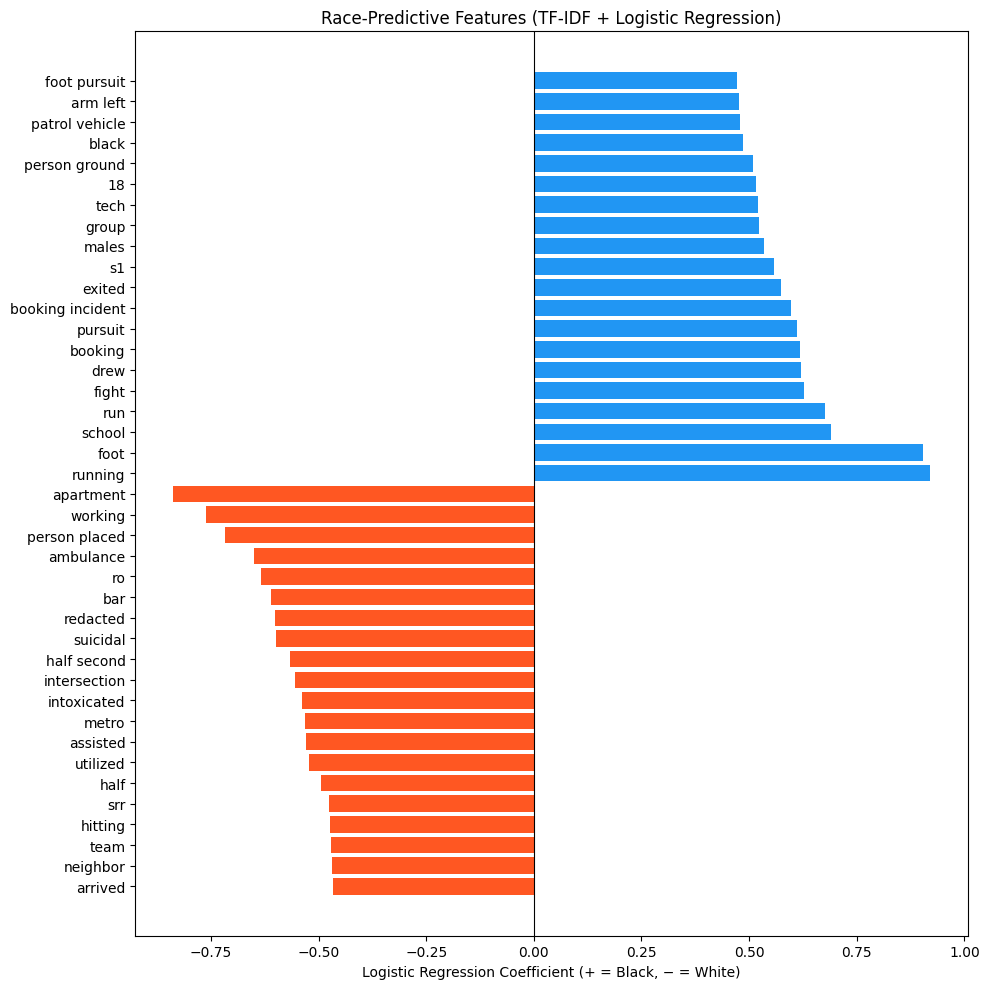

In [5]:
# Feature coefficient visualization
n_show = 20
top_b = sorted(zip(coefs, features), reverse=True)[:n_show]
top_w = sorted(zip(coefs, features))[:n_show]
plot_items = top_w[::-1] + top_b
words_plot = [w for _, w in plot_items]
coefs_plot = [c for c, _ in plot_items]

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#FF5722' if c < 0 else '#2196F3' for c in coefs_plot]
ax.barh(words_plot, coefs_plot, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (+ = Black, − = White)')
ax.set_title('Race-Predictive Features (TF-IDF + Logistic Regression)')
plt.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/05_race_inference_features.png', dpi=150)
plt.show()

## 3. Claude API Race Inference

In [6]:
RACE_INFER_PROMPT = """You are a researcher studying implicit bias in police reports.
Read the following police narrative (race has been redacted) and make your best inference.

Based ONLY on writing style, vocabulary choices, and narrative framing,
estimate the likely race of the subject:

Options: Black, White, Hispanic, Asian, Cannot Determine

Return JSON only:
{{"predicted_race": "...", "confidence": 0.0-1.0, "reasoning": "brief explanation of linguistic cues"}}

Narrative:
{narrative}"""

def infer_race_claude(narrative, model=config.CLAUDE_FAST):
    try:
        resp = client.messages.create(
            model=model,
            max_tokens=200,
            messages=[{"role": "user", "content": RACE_INFER_PROMPT.format(
                narrative=str(narrative)[:2000]
            )}]
        )
        text = resp.content[0].text
        match = re.search(r'\{[\s\S]*\}', text)
        return json.loads(match.group()) if match else None
    except Exception as e:
        print(f'Error: {type(e).__name__}: {e}')
        return None

print('Testing Claude race inference...')
print(f'Using model: {config.CLAUDE_FAST}')
test_black = df[df['race']=='Black'][nar_col].iloc[0]
test_white = df[df['race']=='White'][nar_col].iloc[0]

r_b = infer_race_claude(test_black)
r_w = infer_race_claude(test_white)
print(f'Black narrative → Claude: {r_b}')
print(f'White narrative → Claude: {r_w}')


Testing Claude race inference...
Using model: claude-haiku-4-5-20251001
Black narrative → Claude: {'predicted_race': 'Cannot Determine', 'confidence': 0.95, 'reasoning': 'This narrative contains no linguistic markers, vocabulary choices, or framing patterns that correlate reliably with racial identification. The language is standardized police procedural documentation focused on describing actions, compliance, and physical control techniques. No descriptive adjectives, cultural references, or stereotypical characterizations that research has associated with racial bias in police narratives are present. The report maintains consistent formal tone throughout regardless of subject behavior.'}
White narrative → Claude: {'predicted_race': 'Cannot Determine', 'confidence': 0.45, 'reasoning': 'The narrative contains no explicit linguistic markers, cultural references, or descriptive language that reliably indicates race. The writing style is formal and procedural throughout. While some resear

In [8]:
# Score 200 narratives (100 per race)
N_INFER = 100
sample = pd.concat([
    df[df['race'] == race].sample(min(N_INFER, len(df[df['race'] == race])), random_state=config.RANDOM_SEED)
    for race in ['Black', 'White']
]).reset_index(drop=True)

print(f'Running Claude inference on {len(sample)} narratives...')
infer_results = []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Inferring'):
    result = infer_race_claude(str(row[nar_col])[:2000])
    if result:
        result['true_race'] = row['race']
        result['cr_number'] = row.get('cr_number','')
        infer_results.append(result)

infer_df = pd.DataFrame(infer_results)
print(f'\nTotal scored: {len(infer_df)}')
print('\nPredicted race distribution:')
print(infer_df['predicted_race'].value_counts())

# Accuracy for definitive predictions only
definitive = infer_df[infer_df['predicted_race'].isin(['Black','White'])].copy()
print(f'\nDefinitive predictions: {len(definitive)} / {len(infer_df)} ({100*len(definitive)/len(infer_df):.1f}%)')

if len(definitive) > 10:
    correct = (definitive['predicted_race'] == definitive['true_race']).mean()
    ba_llm = balanced_accuracy_score(
        (definitive['true_race']=='Black').astype(int),
        (definitive['predicted_race']=='Black').astype(int)
    )
    print(f'Accuracy (on definitive): {correct:.4f}')
    print(f'Balanced accuracy (on definitive): {ba_llm:.4f}')
    print(classification_report(definitive['true_race'], definitive['predicted_race']))


Running Claude inference on 200 narratives...


Inferring:   0%|          | 0/200 [00:00<?, ?it/s]


Total scored: 198

Predicted race distribution:
predicted_race
Cannot Determine    192
Hispanic              3
Black                 2
Asian                 1
Name: count, dtype: int64

Definitive predictions: 2 / 198 (1.0%)


In [9]:
# Save inference results
infer_df.to_json(config.RACE_INFER_OUT, orient='records', indent=2)
print(f'Saved → {config.RACE_INFER_OUT}')

Saved → ../../notebooks/analysis/outputs/race_inference_v2.json


## 4. LIME Explanations (if installed)

In [10]:
try:
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
    print('LIME available.')
except ImportError:
    LIME_AVAILABLE = False
    print('LIME not installed. Run: pip install lime')
    print('Skipping LIME section.')

if LIME_AVAILABLE:
    explainer = LimeTextExplainer(class_names=['White','Black'])
    
    def predict_proba(texts):
        return pipeline.predict_proba(texts)
    
    # Explain 5 Black and 5 White narratives
    lime_results = {'Black': [], 'White': []}
    
    for race in ['Black','White']:
        samples = df[df['race']==race].sample(5, random_state=config.RANDOM_SEED)
        for _, row in samples.iterrows():
            text = str(row[nar_col])
            exp = explainer.explain_instance(text, predict_proba, num_features=10, num_samples=500)
            features_weights = exp.as_list()
            lime_results[race].append(features_weights)
    
    # Aggregate top LIME features by race
    from collections import defaultdict
    feature_importance = defaultdict(list)
    
    for race in ['Black','White']:
        for explanation in lime_results[race]:
            for feat, weight in explanation:
                feature_importance[f'{race}_{feat}'].append(weight)
    
    print('\nTop LIME features (aggregated across 5 Black narratives):')
    for explanation in lime_results['Black'][:3]:
        top = sorted(explanation, key=lambda x: abs(x[1]), reverse=True)[:5]
        print(top)

LIME available.

Top LIME features (aggregated across 5 Black narratives):
[('Ofc', 0.0320953177002186), ('child', 0.021332479832451602), ('approximately', 0.01759193162962968), ('stance', 0.015267942614237714), ('body', 0.014764114242667097)]
[('PURSUIT', 0.030358838169545207), ('GROUP', 0.019351727158260765), ('RUNNING', 0.017399084538484218), ('EXITED', 0.013206614763349138), ('FAMILY', 0.012887785205272612)]
[('pursuit', 0.03459203300036852), ('Ofc', 0.02618312431234555), ('Booking', 0.021592961714255697), ('took', 0.01812084459022899), ('tech', 0.017181674701650544)]


## 5. Erasure Experiment (Fixed)

In [11]:
# Erasure experiment:
# Remove top-N differential words → re-evaluate accuracy
# v1 bug: accuracy barely changed even after removing 500 words
# Fix: compute log-odds on train set only, measure on held-out test

# Load log-odds results
if os.path.exists(config.LOG_ODDS_OUT):
    lo_df = pd.read_csv(config.LOG_ODDS_OUT)
    lo_df = lo_df.sort_values('z_score', key=abs, ascending=False)
    all_diff_words = lo_df['word'].tolist()
    print(f'Loaded {len(all_diff_words)} differential words from log-odds analysis')
else:
    print('Run 01_log_odds_fasttext_v2.ipynb first to get log-odds results')
    # Compute inline
    from sklearn.feature_extraction.text import CountVectorizer
    cv_temp = CountVectorizer(max_features=10000, ngram_range=(1,1), min_df=3)
    cv_temp.fit(texts)
    all_diff_words = list(cv_temp.vocabulary_.keys())

# Erasure at different cutoffs
erasure_steps = [0, 10, 50, 100, 200, 500, 1000]

# Use temporal split if available, else random
split_col = 'temporal_split' if 'temporal_split' in df.columns else None

if split_col:
    train_mask = df[split_col] == 'train'
    test_mask  = df[split_col] == 'test'
    X_train_er = [texts[i] for i in range(len(texts)) if train_mask.iloc[i]]
    X_test_er  = [texts[i] for i in range(len(texts)) if test_mask.iloc[i]]
    y_train_er = labels[train_mask.values]
    y_test_er  = labels[test_mask.values]
    print(f'Train: {len(X_train_er)}, Test: {len(X_test_er)}')
else:
    X_train_er, X_test_er, y_train_er, y_test_er = train_test_split(
        texts, labels, test_size=0.2, random_state=config.RANDOM_SEED, stratify=labels
    )

erasure_results = []
for n_remove in tqdm(erasure_steps, desc='Erasure'):
    words_to_remove = set(all_diff_words[:n_remove]) if n_remove > 0 else set()
    
    def erase_words(text):
        tokens = text.split()
        return ' '.join(t for t in tokens if t.lower() not in words_to_remove)
    
    X_train_e = [erase_words(t) for t in X_train_er]
    X_test_e  = [erase_words(t) for t in X_test_er]
    
    pipe_e = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                   stop_words=STOPWORDS, min_df=3, sublinear_tf=True)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'))
    ])
    pipe_e.fit(X_train_e, y_train_er)
    y_pred_e = pipe_e.predict(X_test_e)
    ba_e = balanced_accuracy_score(y_test_er, y_pred_e)
    erasure_results.append({'n_removed': n_remove, 'balanced_acc': ba_e})

er_df = pd.DataFrame(erasure_results)
print('\nErasure experiment results:')
print(er_df.to_string(index=False))

Loaded 4234 differential words from log-odds analysis


Erasure:   0%|          | 0/7 [00:00<?, ?it/s]


Erasure experiment results:
 n_removed  balanced_acc
         0         0.575
        10         0.575
        50         0.595
       100         0.590
       200         0.530
       500         0.520
      1000         0.485


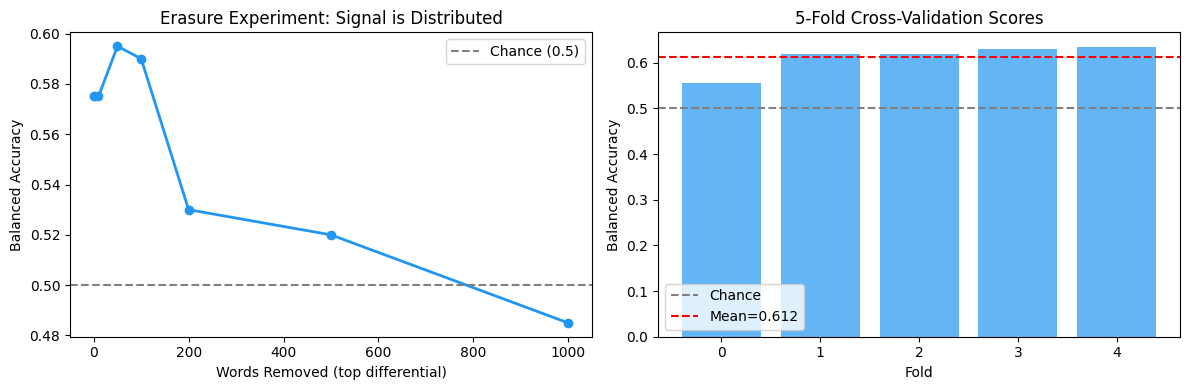

In [12]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Erasure curve
axes[0].plot(er_df['n_removed'], er_df['balanced_acc'], 'o-', color='#2196F3', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', label='Chance (0.5)')
axes[0].set_xlabel('Words Removed (top differential)')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Erasure Experiment: Signal is Distributed')
axes[0].legend()

# Cross-val scores distribution
axes[1].bar(range(len(ba_scores)), sorted(ba_scores), color='#2196F3', alpha=0.7)
axes[1].axhline(0.5, color='gray', linestyle='--', label='Chance')
axes[1].axhline(ba_scores.mean(), color='red', linestyle='--', label=f'Mean={ba_scores.mean():.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('5-Fold Cross-Validation Scores')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/05_race_inference_erasure.png', dpi=150)
plt.show()